# TensorFlow: Simple Object Detection

Using pre-trained model from TensorFlow Hub

In [58]:
import io
import numpy as np
import matplotlib.pyplot as plt
import tempfile
import requests
from PIL import Image
from PIL import ImageColor
from PIL import ImageDraw
from PIL import ImageFont
from PIL import ImageOps

In [44]:
import tensorflow as tf
import tensorflow_hub as hub

print("TF Version: ", tf.__version__)
print("TF Eager mode: ", tf.executing_eagerly())
print("TF GPU is", "available" if tf.config.list_physical_devices("GPU") else "not available")

TF Version:  2.20.0
TF Eager mode:  True
TF GPU is available


## Download pre-trained model

In [45]:
module_handle = "https://tfhub.dev/google/faster_rcnn/openimages_v4/inception_resnet_v2/1"

In [46]:
model = hub.load(module_handle)

INFO:tensorflow:Saver not created because there are no variables in the graph to restore


INFO:tensorflow:Saver not created because there are no variables in the graph to restore


In [47]:
detector = model.signatures["default"]

## Download image

In [48]:
image_url = "https://upload.wikimedia.org/wikipedia/commons/f/fb/20130807_dublin014.JPG"

In [49]:
def download_and_resize(url, width, height):
    headers = {"User-Agent": "TF/1.0 (denoming@gmail.com)"}
    response = requests.get(url, headers=headers)
    image_data = io.BytesIO(response.content)

    _, file_path = tempfile.mkstemp(suffix=".jpg")

    pil_image = Image.open(image_data)
    pil_image = ImageOps.fit(pil_image, (width, height), Image.Resampling.LANCZOS)
    pil_image_rgb = pil_image.convert("RGB")
    pil_image_rgb.save(file_path, format="JPEG", quality=90)

    return file_path

In [50]:
image_path = download_and_resize(image_url, width=1920, height=1024)

## Run detection

In [51]:
def load_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    return image

In [52]:
def run_detector(detector, image):
    conv_image = tf.image.convert_image_dtype(image, tf.float32)[tf.newaxis, ...]
    result = detector(conv_image)
    result = {k:v.numpy() for k,v in result.items()}
    return result

In [53]:
image = load_image(image_path)
result = run_detector(detector, image)

W0000 00:00:1773510618.849078   14745 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "CropAndResize" attr { key: "T" value { type: DT_FLOAT } } attr { key: "extrapolation_value" value { f: 0 } } attr { key: "method" value { s: "bilinear" } } inputs { dtype: DT_FLOAT shape { dim { size: -2484 } dim { size: -2485 } dim { size: -2486 } dim { size: 1088 } } } inputs { dtype: DT_FLOAT shape { dim { size: -105 } dim { size: 4 } } } inputs { dtype: DT_INT32 shape { dim { size: -105 } } } inputs { dtype: DT_INT32 shape { dim { size: 2 } } value { dtype: DT_INT32 tensor_shape { dim { size: 2 } } int_val: 17 } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce RTX 3080" frequency: 1710 num_cores: 68 environment { key: "architecture" value: "8.6" } environment { key: "cuda" value: "12050" } environment { key: "cudnn" value: "90300" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 5242880 shared_memory_size_per_multiprocessor: 102400 memory_size: 71544

In [ ]:
print(f"Found {len(result["detection_scores"])} detected objects:")
print(f"...{result["detection_scores"]}")
print(f"...{result["detection_class_entities"]}")
print(f"...{result["detection_boxes"]}")

## Display result

In [61]:
def font_getsize(font, text):
    """
    Get text width and height for a given font.
    This is used by draw_bounding_box_on_image()
    """

    left, top, right, bottom = font.getbbox(text)

    return right - left, bottom - top

In [54]:
def display_image(image):
    """
    Displays an image inside the notebook.
    This is used by download_and_resize_image()
    """
    fig = plt.figure(figsize=(20, 15))
    plt.grid(False)
    plt.imshow(image)

In [63]:
def draw_bounding_box_on_image(image,
                               ymin,
                               xmin,
                               ymax,
                               xmax,
                               color,
                               font,
                               thickness=4,
                               display_str_list=()):

    """
    Adds a bounding box to an image.

    Args:
        image -- the image object
        ymin -- bounding box coordinate
        xmin -- bounding box coordinate
        ymax -- bounding box coordinate
        xmax -- bounding box coordinate
        color -- color for the bounding box edges
        font -- font for class label
        thickness -- edge thickness of the bounding box
        display_str_list -- class labels for each object detected


    Returns:
        No return.  The function modifies the `image` argument
                    that gets passed into this function

    """
    draw = ImageDraw.Draw(image)
    im_width, im_height = image.size

    # scale the bounding box coordinates to the height and width of the image
    (left, right, top, bottom) = (xmin * im_width, xmax * im_width,
                                ymin * im_height, ymax * im_height)

    # define the four edges of the detection box
    draw.line([(left, top), (left, bottom), (right, bottom), (right, top),
             (left, top)],
            width=thickness,
            fill=color)

    # If the total height of the display strings added to the top of the bounding
    # box exceeds the top of the image, stack the strings below the bounding box
    # instead of above.
    display_str_heights = [font_getsize(font,ds)[1] for ds in display_str_list]
    # Each display_str has a top and bottom margin of 0.05x.
    total_display_str_height = (1 + 2 * 0.05) * sum(display_str_heights)

    if top > total_display_str_height:
        text_bottom = top
    else:
        text_bottom = top + total_display_str_height

    # Reverse list and print from bottom to top.
    for display_str in display_str_list[::-1]:
        text_width, text_height = font_getsize(font, display_str)
        margin = np.ceil(0.05 * text_height)
        draw.rectangle([(left, text_bottom - text_height - 2 * margin),
                        (left + text_width, text_bottom)],
                       fill=color)
        draw.text((left + margin, text_bottom - text_height - margin),
                  display_str,
                  fill="black",
                  font=font)
        text_bottom -= text_height - 2 * margin

In [66]:
def draw_boxes(image, boxes, class_names, scores, max_boxes=10, min_score=0.1):
    """
    Overlay labeled boxes on an image with formatted scores and label names.

    Args:
        image -- the image as a numpy array
        boxes -- list of detection boxes
        class_names -- list of classes for each detected object
        scores -- numbers showing the model's confidence in detecting that object
        max_boxes -- maximum detection boxes to overlay on the image (default is 10)
        min_score -- minimum score required to display a bounding box

    Returns:
        image -- the image after detection boxes and classes are overlaid on the original image.
    """
    colors = list(ImageColor.colormap.values())

    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Regular.ttf",
                              25)
    except IOError:
        print("Font not found, using default font.")
        font = ImageFont.load_default()

    for i in range(min(boxes.shape[0], max_boxes)):
        if scores[i] >= min_score:
            ymin, xmin, ymax, xmax = tuple(boxes[i])
            display_str = "{}: {}%".format(class_names[i].decode("ascii"), int(100 * scores[i]))
            color = colors[hash(class_names[i]) % len(colors)]
            image_pil = Image.fromarray(np.uint8(image)).convert("RGB")
            draw_bounding_box_on_image(image_pil,
                                       ymin,
                                       xmin,
                                       ymax,
                                       xmax,
                                       color,
                                       font,
                                       display_str_list=[display_str])
            np.copyto(image, np.array(image_pil))

    return image

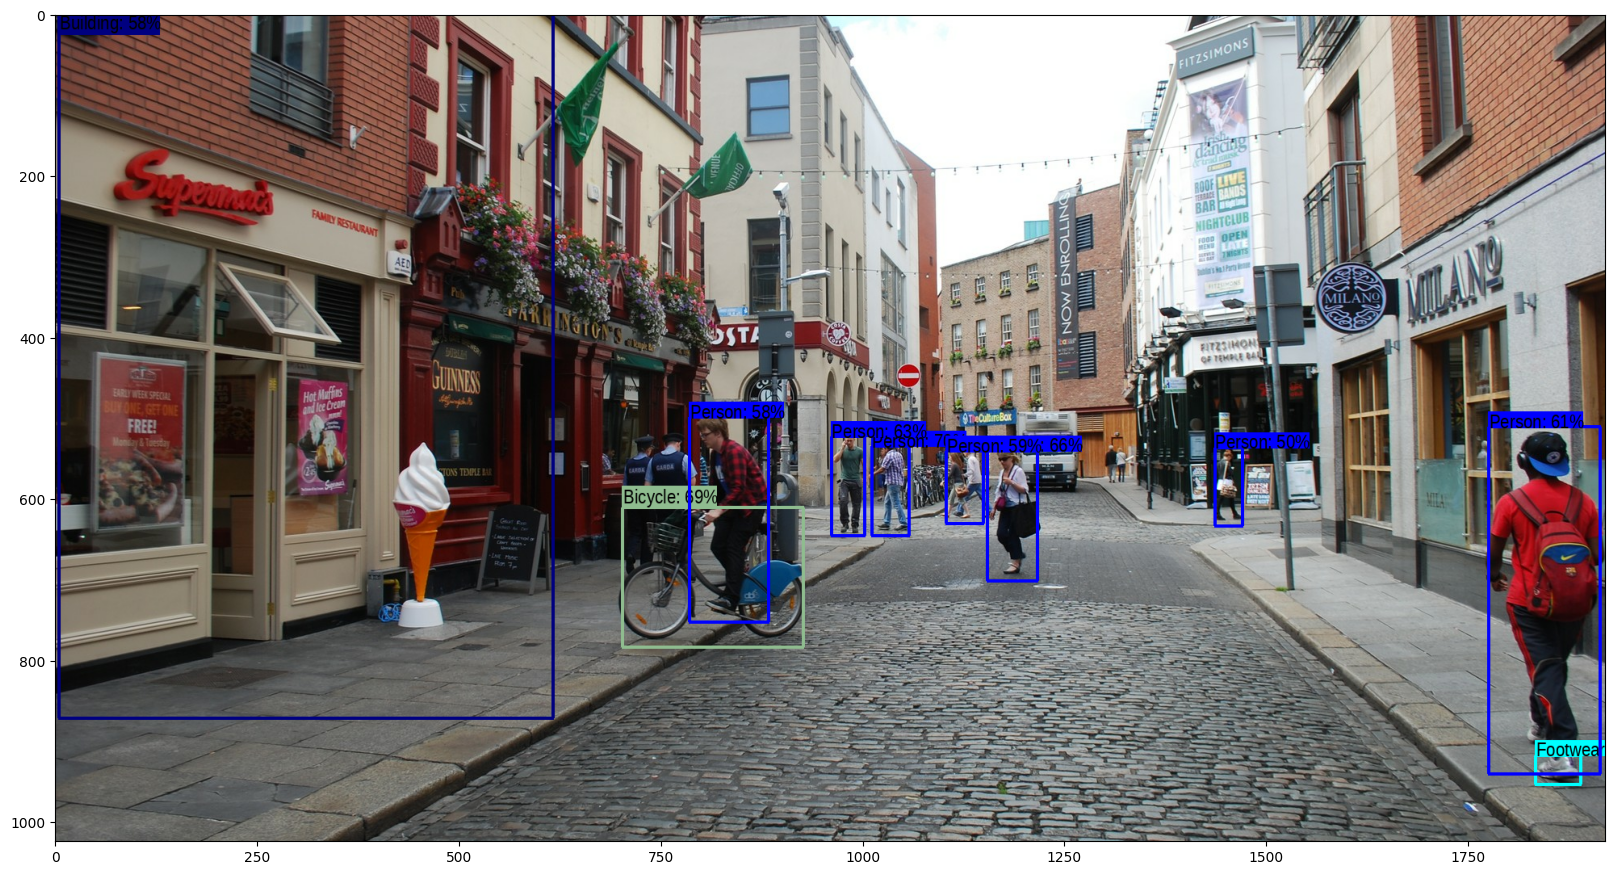

In [67]:
image_with_boxes = draw_boxes(
    image.numpy(),
    result["detection_boxes"],
    result["detection_class_entities"],
    result["detection_scores"])

display_image(image_with_boxes)